In [3]:
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, glob
import nilearn 
import nibabel as nib
from nibabel import processing
from config import *
import RM_utils as utils
from nibabel import Nifti1Image
from nilearn import datasets
from scipy import stats
from nilearn import plotting
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from brainiak.searchlight.searchlight import Searchlight
import tphate#from TPHATE.tphate import tphate
import scprep
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
from scipy.spatial.distance import pdist, cdist, squareform

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
subjects_by_task = {}
for k,d in RM_DATA_DIRS.items():
    filenames = sorted(glob.glob(f'{d}/{RM_STRING_MATCH}'))
    subjects = [f.split('/')[-1].split('_functional')[0] for f in filenames]
    subjects_by_task[k] = subjects

In [10]:
common = set.intersection(*map(set, [subjects_by_task[k] for k in RM_DATA_DIRS.keys()]))

In [11]:
common

{'rest_movie_01',
 'rest_movie_02',
 'rest_movie_03',
 'rest_movie_04',
 'rest_movie_05',
 'rest_movie_07',
 'rest_movie_08',
 'rest_movie_09',
 'rest_movie_10',
 'rest_movie_11',
 'rest_movie_12'}

In [9]:
subjects_by_task

{'REST': ['rest_movie_01',
  'rest_movie_02',
  'rest_movie_03',
  'rest_movie_04',
  'rest_movie_05',
  'rest_movie_06',
  'rest_movie_07',
  'rest_movie_08',
  'rest_movie_09',
  'rest_movie_10',
  'rest_movie_11',
  'rest_movie_12'],
 'AERONAUT': ['rest_movie_01',
  'rest_movie_02',
  'rest_movie_03',
  'rest_movie_04',
  'rest_movie_05',
  'rest_movie_06',
  'rest_movie_07',
  'rest_movie_08',
  'rest_movie_09',
  'rest_movie_10',
  'rest_movie_11',
  'rest_movie_12'],
 'MICKEY': ['rest_movie_01',
  'rest_movie_02',
  'rest_movie_03',
  'rest_movie_04',
  'rest_movie_05',
  'rest_movie_07',
  'rest_movie_08',
  'rest_movie_09',
  'rest_movie_10',
  'rest_movie_11',
  'rest_movie_12']}

In [2]:
cmap = utils.get_brain_cmap(mpl_colorname='inferno')

In [3]:
isc_mickey = nib.load(f'RestMovie/results/ISC/average_MICKEY_ISC_whole_brain_SL_rad5.nii.gz')
mickey_mask = utils.get_mask("MICKEY")

isc_aero = nib.load(f'RestMovie/results/ISC/average_AERONAUT_ISC_whole_brain_SL_rad5.nii.gz')
aero_mask = utils.get_mask("AERONAUT")

rest_mask = utils.get_mask("REST")
rest_mask_data = rest_mask.get_fdata()

intersect_mask = nib.load(f'./masks/Mickey_Aeronaut_intersect.nii.gz')
common_coords = np.where(intersect_mask.get_fdata() == 1)
isc_mickey_masked = isc_mickey.get_fdata()[common_coords]
isc_aero_masked = isc_aero.get_fdata()[common_coords]
print(isc_mickey_masked.shape == isc_aero_masked.shape)

True


In [7]:
mickey_mask_data = mickey_mask.get_fdata()
aero_mask_data = aero_mask.get_fdata()

intersect_vol = np.zeros_like(mickey_mask_data)
intersect = np.where(mickey_mask_data + aero_mask_data == 2)
print(np.shape(intersect))
intersect_vol[intersect] = 1
print(np.sum(intersect_vol))
nii=Nifti1Image(intersect_vol,  affine=mickey_mask.affine)
nib.save(nii,"masks/Mickey_Aeronaut_intersect.nii.gz")

intersect_vol = np.zeros_like(mickey_mask_data)
intersect = np.where(mickey_mask_data + aero_mask_data + rest_mask_data == 3)
print(np.shape(intersect))
intersect_vol[intersect] = 1
print(np.sum(intersect_vol))
nii=Nifti1Image(intersect_vol,  affine=mickey_mask.affine)
nib.save(nii,"masks/Mickey_Aeronaut_Rest_intersect.nii.gz")

(3, 70868)
70868.0
(3, 69408)
69408.0


In [4]:
all_intersect_mask = nib.load(f'./masks/Mickey_Aeronaut_intersect.nii.gz').get_fdata()
all_common_coords = np.where(all_intersect_mask == 1)

dim_aero = nib.load(f'RestMovie/results/AGGREGATE/average_optimal_t_AERONAUT_sl_rad5.nii.gz').get_fdata()[all_common_coords]
dim_mickey = nib.load(f'RestMovie/results/AGGREGATE/average_optimal_t_MICKEY_sl_rad5.nii.gz').get_fdata()[all_common_coords]
dim_rest = nib.load(f'RestMovie/results/AGGREGATE/average_optimal_t_MICKEY_sl_rad5.nii.gz').get_fdata()[all_common_coords]

dim_aero_pca = nib.load(f'RestMovie/results/SEARCHLIGHT/PCA/average_PCA_95p_var_AERONAUT_sl_rad5.nii.gz').get_fdata()[all_common_coords]
dim_mickey_pca = nib.load(f'RestMovie/results/SEARCHLIGHT/PCA/average_PCA_95p_var_MICKEY_sl_rad5.nii.gz').get_fdata()[all_common_coords]
dim_rest_pca = nib.load(f'RestMovie/results/SEARCHLIGHT/PCA/average_PCA_95p_var_REST_sl_rad5.nii.gz').get_fdata()[all_common_coords]

dim_aero_phate = nib.load(f'RestMovie/results/SEARCHLIGHT/PHATE/average_phate_optt_AERONAUT_sl_rad5.nii.gz').get_fdata()[all_common_coords]
dim_mickey_phate = nib.load(f'RestMovie/results/SEARCHLIGHT/PHATE/average_phate_optt_MICKEY_sl_rad5.nii.gz').get_fdata()[all_common_coords]
dim_rest_phate = nib.load(f'RestMovie/results/SEARCHLIGHT/PHATE/average_phate_optt_REST_sl_rad5.nii.gz').get_fdata()[all_common_coords]

isc_mickey_masked = nib.load(f'RestMovie/results/ISC/average_MICKEY_ISC_whole_brain_SL_rad5.nii.gz').get_fdata()[all_common_coords]
isc_aero_masked = nib.load(f'RestMovie/results/ISC/average_AERONAUT_ISC_whole_brain_SL_rad5.nii.gz').get_fdata()[all_common_coords]

## Significance testing for ISCs

In [6]:
## Significance testing for ISCs
from brainiak.isc import bootstrap_isc

# load iscs
mickey_isc_array = []
for fn in sorted(glob.glob(f'RestMovie/results/ISC/sub*MICKEY*SL_rad5*')):
    data = nib.load(fn).get_fdata()[all_common_coords]
    mickey_isc_array.append(data)
mickey_isc_array = np.array(mickey_isc_array)    

# load iscs
aero_isc_array = []
for fn in sorted(glob.glob(f'RestMovie/results/ISC/sub*AERO*SL_rad5*')):
    data = nib.load(fn).get_fdata()[all_common_coords]
    aero_isc_array.append(data)
aero_isc_array = np.array(aero_isc_array)

In [85]:
aero_results = bootstrap_isc(aero_isc_array)
mickey_results = bootstrap_isc(mickey_isc_array, summary_statistic='mean',side='two-sided')
np.save(f'RestMovie/results/ISC/mickey_ISC_bootstrap.npy', mickey_results)
np.save(f'RestMovie/results/ISC/aero_ISC_bootstrap.npy', aero_results)


(<Figure size 384x288 with 3 Axes>,
  <matplotlib.axes._subplots.AxesSubplot at 0x2b49e143f6d8>])

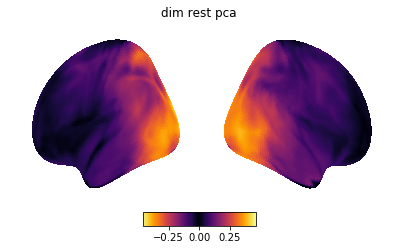

In [79]:
array = np.zeros_like(mickey_mask_data)
array[all_common_coords] = np.squeeze(aero_results[0])
nii=Nifti1Image(array, affine=mickey_mask.affine)

plotting.plot_img_on_surf(nii, 
                          views=['lateral'], inflate=True, cmap=cmap, bg_on_data=False, 
                                  alpha=0.8, darkness=0.8, title='')

(<Figure size 384x288 with 3 Axes>,
  <matplotlib.axes._subplots.AxesSubplot at 0x2b49513927b8>])

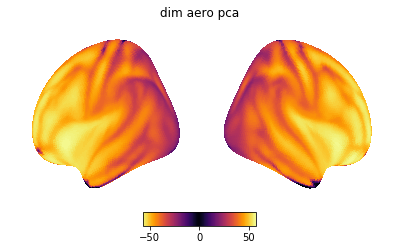

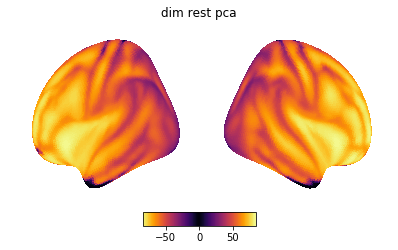

In [51]:
plotting.plot_img_on_surf(f'RestMovie/results/SEARCHLIGHT/PCA/average_PCA_95p_var_AERONAUT_sl_rad5.nii.gz', 
                          views=['lateral'], inflate=True, cmap=cmap, bg_on_data=False, 
                                  alpha=0.8, darkness=0.8, title='dim aero pca')
plotting.plot_img_on_surf(f'RestMovie/results/SEARCHLIGHT/PCA/average_PCA_95p_var_REST_sl_rad5.nii.gz', 
                          views=['lateral'], inflate=True, cmap=cmap, bg_on_data=False, 
                                  alpha=0.8, darkness=0.8, title='dim rest pca')

In [23]:
sub_data = []
sub_corrs = []
tph_dir = 'RestMovie/results/SEARCHLIGHT/TPHATE/'

for sub in config.RM_SUBJECTS['MICKEY']:
    task_data = []
    for task in ['AERONAUT','MICKEY',"REST"]:
        data=nib.load(f'{tph_dir}/sub-{sub:02d}_{task}_optimal_t_whole_brain_SL_rad5.nii.gz').get_fdata()[all_common_coords]
        task_data.append(data)
    task_data = np.array(task_data)
    sub_data.append(task_data)
sub_data = np.array(sub_data)
    
np.save("RestMovie/results/AERONAUT_tphate_optt_slrad5_allintersect.npy", sub_data[:,0,:])
np.save("RestMovie/results/MICKEY_tphate_optt_slrad5_allintersect.npy", sub_data[:,1,:])
np.save("RestMovie/results/REST_tphate_optt_slrad5_allintersect.npy", sub_data[:,2,:])
    

In [29]:
sub_data = []
sub_corrs = []
tph_dir = 'RestMovie/results/ISC/'

for sub in config.RM_SUBJECTS['MICKEY'][:-1]:
    task_data = []
    for task in ['AERONAUT','MICKEY']:
        data=nib.load(f'{tph_dir}/sub-{sub:02d}_{task}_ISC_whole_brain_SL_rad5.nii.gz').get_fdata()[all_common_coords]
        task_data.append(data)
    task_data = np.array(task_data)
    sub_data.append(task_data)
sub_data = np.array(sub_data)
    
np.save("RestMovie/results/AERONAUT_ISC_slrad5_allintersect.npy", sub_data[:,0,:])
np.save("RestMovie/results/MICKEY_ISC_slrad5_allintersect.npy", sub_data[:,1,:])
    

In [27]:
# correlate movie ISC with rest DIM 

aero_isc = np.load("RestMovie/results/AERONAUT_ISC_slrad5_allintersect.npy")
mickey_isc = np.load("RestMovie/results/MICKEY_ISC_slrad5_allintersect.npy")
rest_dim = np.load("RestMovie/results/REST_tphate_optt_slrad5_allintersect.npy")
mickey_dim = np.load("RestMovie/results/MICKEY_tphate_optt_slrad5_allintersect.npy")
aero_dim = np.load("RestMovie/results/AERONAUT_tphate_optt_slrad5_allintersect.npy")

print(aero_isc.shape, mickey_isc.shape, rest_dim.shape)
print(np.sum(aero_isc == 0), np.sum(mickey_isc == 0), np.sum(rest_dim==0))


(10, 70868) (10, 70868) (11, 70868)
560 560 16533


In [28]:
rest_mickey = rest_dim - mickey_dim
rest_aero = rest_dim - aero_dim

In [ ]:
X = []
rest_dim

In [32]:
X = []
for i, diff in zip(['rest-mickey','rest-aero'], [rest_mickey, rest_aero]):
    for j, isc in zip(['mickey_isc','aero_isc'], [mickey_isc, aero_isc]):
        a = np.mean(diff, axis=0)
        b = np.mean(isc, axis=0)
        r,p = stats.pearsonr(a,b)
        print(i,j,r,p)
        X.append([r, p])

rest-mickey mickey_isc 0.030955965037560342 1.68464456711276e-16
rest-mickey aero_isc 0.04239198465975969 1.469281106078358e-29
rest-aero mickey_isc 0.09936890176407703 5.974808863313737e-155
rest-aero aero_isc 0.11892607752851117 1.5972470093311423e-221


In [61]:
res_df = pd.DataFrame(columns=['subject','comparison','r','p'])
for i in range(10):
    mask = np.where((aero_isc[i]!=0) + (rest_dim[i]!=0))[0]
    r,p = stats.pearsonr(aero_isc[i,mask], rest_dim[i,mask])
    res_df.loc[len(res_df)] = {'subject':i+1, 'comparison':'aero_isc_v_rest_dim', 'r':r, 'p':p}
    
    mask = np.where((mickey_isc[i]!=0) + (rest_dim[i]!=0))[0]
    r,p = stats.pearsonr(mickey_isc[i,mask], rest_dim[i,mask])
    res_df.loc[len(res_df)] = {'subject':i+1, 'comparison':'mickey_isc_v_rest_dim', 'r':r, 'p':p}
    
    r,p = stats.pearsonr(mickey_isc[i], aero_dim[i])
    res_df.loc[len(res_df)] = {'subject':i+1, 'comparison':'mickey_isc_v_aero_dim', 'r':r, 'p':p}
    
    r,p = stats.pearsonr(aero_isc[i], aero_dim[i])
    res_df.loc[len(res_df)] = {'subject':i+1, 'comparison':'aero_isc_v_aero_dim', 'r':r, 'p':p}
    
    r,p = stats.pearsonr(mickey_isc[i], mickey_dim[i])
    res_df.loc[len(res_df)] = {'subject':i+1, 'comparison':'mickey_isc_v_mickey_dim', 'r':r, 'p':p}
    
    r,p = stats.pearsonr(aero_isc[i], mickey_dim[i])
    res_df.loc[len(res_df)] = {'subject':i+1, 'comparison':'aero_isc_v_mickey_dim', 'r':r, 'p':p}
    

In [93]:
res_df.groupby("comparison").median()

,r,p
comparison,,
aero_isc_v_aero_dim,0.474842,0.0
aero_isc_v_mickey_dim,0.469110,0.0
aero_isc_v_rest_dim,0.324486,0.0
mickey_isc_v_aero_dim,0.507582,0.0
mickey_isc_v_mickey_dim,0.494970,0.0
mickey_isc_v_rest_dim,0.388629,0.0


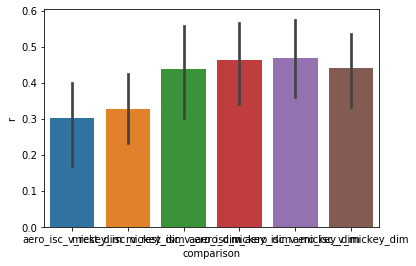

In [62]:
sns.barplot(x='comparison', y='r', data=res_df)

In [85]:
poly = np.polyfit(x=avg, y=rest_avg[mask], deg=1)

In [87]:
xs = np.linspace(0, 0.5, 100)
y1=poly[0]*xs**1 + poly[1]*xs**0
#ys = poly[0]*xs**2 + poly[1]*xs**1 + poly[2]*xs**0

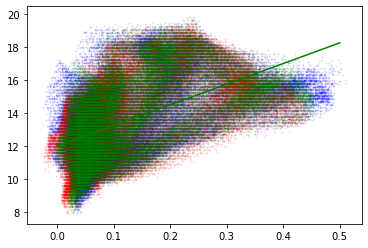

In [89]:
mick_avg = np.mean(mickey_isc, axis=0)
rest_avg = np.mean(rest_dim, axis=0)
aero_avg = np.mean(aero_isc, axis=0)

mask = np.where((rest_avg!=0))[0]
avg = np.mean((aero_avg[mask], mick_avg[mask]),axis=0)
#r,p = stats.pearsonr(mickey_isc[i,mask], rest_dim[i,mask])
fig,ax=plt.subplots()
ax.scatter(x=mick_avg[mask], y=rest_avg[mask], alpha=0.1, c='b', s=1)
ax.scatter(x=aero_avg[mask], y=rest_avg[mask], alpha=0.1, c='r', s=1)
ax.scatter(x=avg, y=rest_avg[mask], c='g', s=1, alpha=0.1)
plt.plot(xs, y1, c='g')


In [6]:
results = np.zeros((2,70868)) 
df = pd.DataFrame(columns=['comparison','sl','value','
for v in range(70868):
    if np.sum((aero_isc[:,v], rest_dim[:,v], mickey_isc[:,v]) == 0):
        results[:,v] = np.nan
        continue
    
    # at every voxel, get a correlation between rest dim and movie isc
    aero_r = np.corrcoef(aero_isc[:,v], rest_dim[:,v])[0,1]
    mick_r = np.corrcoef(mickey_isc[:,v], rest_dim[:,v])[0,1]
    
    # save that
    results[0,v] = aero_r
    results[1,v] = mick_r # correlation of dimensionality at every voxel

In [38]:
from random import choices 
def bootstrap_difference_ci(data1, data2, repetitions = 1000, alpha = 0.05):
    bootstrap_sample_size = len(data1)
    mean_diffs = []
    for i in range(repetitions):
        bootstrap_sample_d1 = choices(data1, k=bootstrap_sample_size)
        bootstrap_sample_d2 = choices(data2, k=bootstrap_sample_size)
        mean_diff = np.mean(bootstrap_sample_d1) - np.mean(bootstrap_sample_d2)
        mean_diffs.append(mean_diff)
    lower = np.percentile(mean_diffs, alpha/2*100)
    upper = np.percentile(mean_diffs, 100-alpha/2*100)
    point_est = data1.mean() - data2.mean()
    return lower, upper, point_est

def bootstrap_mean_ci(data, repetitions = 1000, alpha = 0.05):
    bootstrap_sample_size = len(data)
    means = []
    for i in range(repetitions):
        bootstrap_sample_d = choices(data, k=bootstrap_sample_size)
        means.append(np.mean(bootstrap_sample_d))
    lower = np.percentile(means, alpha/2*100)
    upper = np.percentile(means, 100-alpha/2*100)
    point_est = data.mean()
    return lower, upper, point_est


In [42]:
results = [bootstrap_mean_ci(aero_isc[:, v]) for v in range(aero_isc.shape[1])]

In [36]:
results = [bootstrap_ci(aero_isc[:,v], mickey_isc[:,v])

(-0.04550616127130867, 0.029710195300464586, -0.009124448512827218)

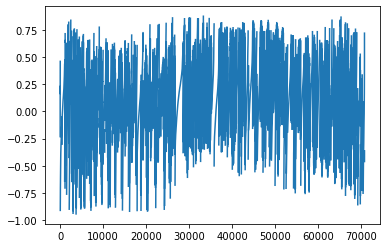

In [21]:
plt.plot(np.arange(results.shape[1]), sorted(results[0]))

In [64]:
np.shape(results)

(70868, 3)

In [8]:
np.nanmean(results)

0.03573663259480197

In [27]:
rest_dim.shape

(10, 70868)

In [13]:
np.polyfit(np.mean(aero_isc,axis=0), np.mean(rest_dim, axis=0), deg=1), stats.spearmanr(np.mean(mickey_isc,axis=0), np.mean(rest_dim, axis=0))

(array([14.73886852, 11.83958946]),
 SpearmanrResult(correlation=0.5414694951151375, pvalue=0.0))

In [11]:
aero_isc[:,v], rest_dim[:,v]

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [10]:
np.corrcoef(aero_isc[:,v], rest_dim[:,v])

array([[nan, nan],
       [nan, nan]])

(<Figure size 460.8x288 with 3 Axes>,
  <matplotlib.axes._subplots.AxesSubplot at 0x2adecdebfbe0>])

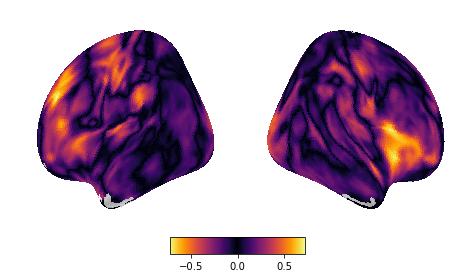

In [51]:
avg_corr = np.nanmean(results,axis=0)
# invert and plot
vol = np.zeros_like(mickey_mask_data)
vol[all_common_coords] = avg_corr
nii=Nifti1Image(vol,  affine=mickey_mask.affine)
plotting.plot_img_on_surf(nii, 
                          views=['lateral'], inflate=True, cmap=cmap, bg_on_data=False, 
                                  alpha=0.8, darkness=0.8)

In [44]:
df2 = pd.DataFrame(data={'subject':np.repeat(np.arange(1,11), 70868),
                         'aero_isc':aero_isc.ravel(),
                         'rest_dim':rest_dim.ravel(),
                         'mickey_isc':mickey_isc.ravel(), 
                        'sl_idx':np.repeat(np.arange(0,70868), 10)})


ValueError: arrays must all be same length

In [55]:
df2 = df2.groupby("sl_idx").mean().reset_index()

In [66]:
meannn = np.mean([df2['aero_isc'], df2['mickey_isc']],axis=0)
stats.spearmanr(meannn, df2['rest_dim'].values)

SpearmanrResult(correlation=0.39737712110037215, pvalue=0.0)

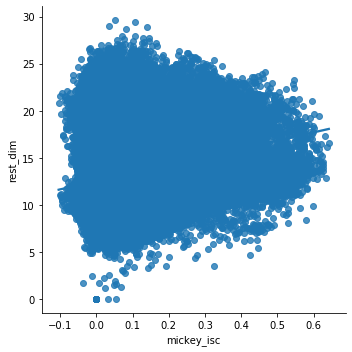

In [59]:
sns.lmplot(x='mickey_isc', y='rest_dim', data=df2)

In [42]:
df2_no = df2[df2.rest_dim != 0]


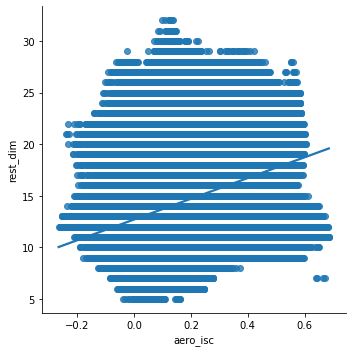

In [45]:
sns.lmplot(data=df2_no, x='aero_isc', y='rest_dim')

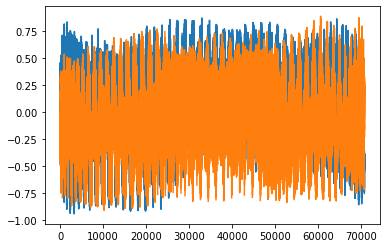

In [35]:
plt.plot(results.T)

In [26]:
np.nanmean(np.array(corrs), axis=0)

array([0.20523472, 0.49152755])

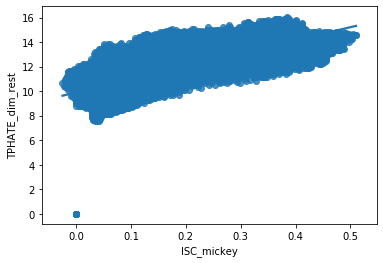

In [93]:
sns.relplot(x='ISC_mickey', y='TPHATE_dim_rest',data=df1)

In [40]:
df1 = pd.DataFrame(data = {'ISC_mickey':isc_mickey_masked, 
                           'ISC_aero':isc_aero_masked, 
                           'TPHATE_dim_mickey':dim_mickey,
                          'TPHATE_dim_aero':dim_aero,
                          'TPHATE_dim_rest':dim_rest,
                          'PCA_dim_mickey':dim_mickey_pca, 
                          'PCA_dim_aero':dim_aero_pca,
                           'PCA_dim_rest':dim_rest_pca,
                           'PHATE_dim_aero':dim_aero_phate,
                           'PHATE_dim_mickey':dim_mickey_phate,
                           'PHATE_dim_rest':dim_rest_phate
                          })

In [43]:
df1.to_csv('RestMovie/results/slrad5_results.csv')

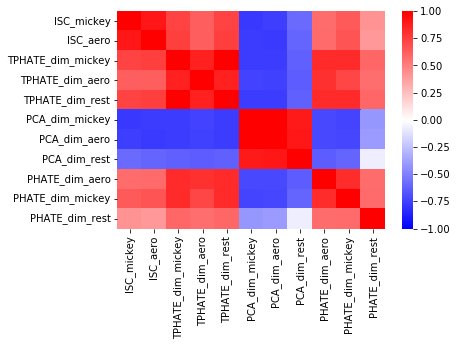

In [54]:
sns.heatmap(df1.corr(),vmin=-1, vmax=1, cmap='bwr')

In [2]:
df = pd.read_csv('RestMovie/results/slrad5_results.csv')

In [3]:
df['Average_ISC'] = np.nanmean(df[['ISC_mickey','ISC_aero']], axis=1)
df['Average_dim'] = np.nanmean(df[['TPHATE_dim_mickey','TPHATE_dim_aero']], axis=1)


In [4]:
stats.spearmanr(df['Average_ISC'].values, df['Average_dim'].values)

SpearmanrResult(correlation=0.7395706719435318, pvalue=0.0)

In [ ]:
df.corr()

In [7]:
stats.pearsonr(df['ISC_mickey'].values, df['TPHATE_dim_aero'].values)

(0.6276783044205805, 0.0)

In [8]:
stats.pearsonr(df['ISC_aero'].values, df['TPHATE_dim_mickey'].values)

(0.7568849305820405, 0.0)

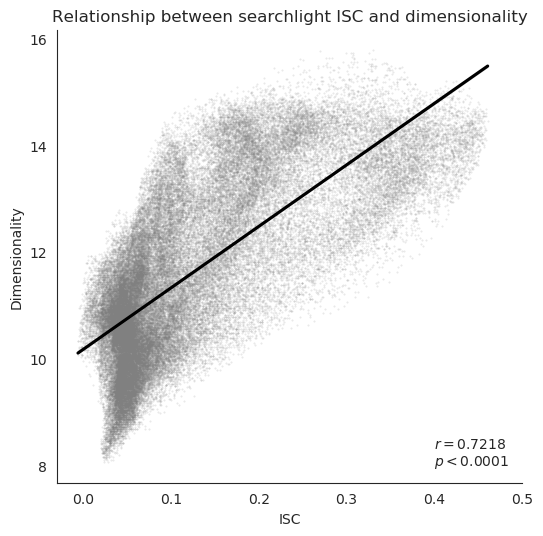

In [6]:
sns.set_style('white')
fig,ax=plt.subplots(dpi=100, figsize=(6,6))
g=sns.regplot(x='Average_ISC', y='Average_dim', color='black',
              data=df.drop(df[df['Average_dim']==0].index), 
              scatter_kws={'alpha':0.2, 's':0.2, "color":'gray'}, ax=ax)
# g=sns.regplot(x='ISC_mickey', y='TPHATE_dim_aero', 
#               data=df.drop(df[df['TPHATE_dim_aero']==0].index), 
#               scatter_kws={'alpha':0.2, 's':0.2, "color":'r'}, ax=ax)
# k=sns.regplot(x='ISC_aero', y='TPHATE_dim_mickey', 
#               data=df.drop(df[df['TPHATE_dim_mickey']==0].index), 
#               scatter_kws={'alpha':0.2, 's':0.2, "color":'g'}, ax=ax)

sns.despine()
_=g.set(xlabel='ISC', ylabel='Dimensionality', xticks=np.arange(0,0.6,0.1), yticks=np.arange(8,18,2), 
      title='Relationship between searchlight ISC and dimensionality')
ax.text(0.4,8,f'$r = 0.7218$\n$p < 0.0001$')
plt.savefig('RestMovie/plots/ISC_vs_IDE.png',transparent=True)